In [1]:
from langchain_community.document_loaders import PyPDFDirectoryLoader

# Charger tous les PDF du dossier data
loader = PyPDFDirectoryLoader("data")

documents = loader.load()

print(f"Nombre de pages chargées : {len(documents)}")

C:\Users\Admin\AppData\Local\Temp\ipykernel_2732\2828094217.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFDirectoryLoader
c:\Users\Admin\Desktop\Master_BDCC\IA_AGENTIQUE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Nombre de pages chargées : 30


In [6]:
print(documents[0].page_content[:102])

Guide de Finance - Base documentaire pour un
projet Agentic RAG
Chapitre 1 : Introduction à la finance


In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(documents)

print(f"Nombre de chunks : {len(chunks)}")

Nombre de chunks : 52


In [9]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

print("Embeddings chargés avec succès.")

C:\Users\Admin\AppData\Local\Temp\ipykernel_2732\1241131181.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 230.24it/s]


Embeddings chargés avec succès.


In [11]:
from langchain_core.vectorstores import InMemoryVectorStore
vector_store = InMemoryVectorStore(embeddings)

ids = vector_store.add_documents(documents=chunks)

results = vector_store.similarity_search(
"Qu'est-ce qu'une action ?"
)
print(results[0])

page_content='Chapitre 3 : Les actions
Une action représente une fraction du capital d'une entreprise. Les actionnaires
peuvent recevoir des dividendes et profiter de la hausse du cours. Une action
représente une fraction du capital d'une entreprise. Les actionnaires peuvent recevoir
des dividendes et profiter de la hausse du cours. Une action représente une fraction du
capital d'une entreprise. Les actionnaires peuvent recevoir des dividendes et profiter
de la hausse du cours. Une action représente une fraction du capital d'une entreprise.
Les actionnaires peuvent recevoir des dividendes et profiter de la hausse du cours. Une
action représente une fraction du capital d'une entreprise. Les actionnaires peuvent
recevoir des dividendes et profiter de la hausse du cours. Une action représente une
fraction du capital d'une entreprise. Les actionnaires peuvent recevoir des dividendes
et profiter de la hausse du cours. Une action représente une fraction du capital d'une' metadata={'producer'

In [12]:
from langchain_ollama import ChatOllama

model = ChatOllama(
    model="llama3.2:3b",
    temperature=0
)

In [23]:
from langchain_core.tools import tool

@tool
def search_finance(question: str) -> str:
    """
    Recherche dans la base documentaire.
    """

    docs = vector_store.similarity_search(
        question,
        k=3
    )

    return "\n\n".join(doc.page_content for doc in docs)

In [24]:
@tool
def answer_finance(question: str) -> str:
    """
    Génère une réponse à partir des documents récupérés.
    """

    context = search_finance.invoke(question)

    prompt = f"""
Tu es un assistant spécialisé en finance.

Réponds uniquement à partir du contexte suivant.

Contexte :
{context}

Question :
{question}

Réponse :
"""

    response = model.invoke(prompt)

    return response.content

In [25]:
tools = [
    search_finance,
    answer_finance
]

print("LLM et Tools initialisés avec succès.")

LLM et Tools initialisés avec succès.


In [27]:
search_finance.invoke(
    "Qu'est-ce qu'une obligation ?"
)

"Chapitre 4 : Les obligations\nUne obligation est un emprunt émis par une entreprise ou un État. Une obligation est\nun emprunt émis par une entreprise ou un État. Une obligation est un emprunt émis\npar une entreprise ou un État. Une obligation est un emprunt émis par une entreprise\nou un État. Une obligation est un emprunt émis par une entreprise ou un État. Une\nobligation est un emprunt émis par une entreprise ou un État. Une obligation est un\nemprunt émis par une entreprise ou un État. Une obligation est un emprunt émis par\nune entreprise ou un État. Une obligation est un emprunt émis par une entreprise ou\nun État. Une obligation est un emprunt émis par une entreprise ou un État. Une\nobligation est un emprunt émis par une entreprise ou un État. Une obligation est un\nemprunt émis par une entreprise ou un État.\n\nquestions-réponses sur les notions financières afin d'alimenter une base documentaire\nRAG. Cette annexe présente des exemples de questions-réponses sur les notions\

In [33]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

from langchain_core.messages import AIMessage

In [34]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

In [35]:
def search_node(state: AgentState):

    question = state["messages"][-1].content

    docs = vector_store.similarity_search(question, k=3)

    context = "\n\n".join(doc.page_content for doc in docs)

    return {
        "messages": [
            AIMessage(content=context)
        ]
    }

In [36]:
def answer_node(state: AgentState):

    context = state["messages"][-1].content

    prompt = f"""
Tu es un assistant spécialisé en finance.

Réponds uniquement à partir du contexte suivant.

Contexte :
{context}
"""

    response = model.invoke(prompt)

    return {
        "messages": [
            AIMessage(content=response.content)
        ]
    }

In [37]:
builder = StateGraph(AgentState)

builder.add_node("search", search_node)
builder.add_node("answer", answer_node)

builder.add_edge(START, "search")
builder.add_edge("search", "answer")
builder.add_edge("answer", END)

In [39]:

memory = MemorySaver()

graph = builder.compile(
    checkpointer=memory
)

print("Graphe créé avec succès.")

Graphe créé avec succès.


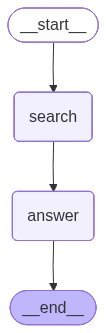

In [40]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)